# Artificial Neural Networks (ANNs)

## Theoretical Background & Backpropagation Derivation

Consider a Neural Network with three layers: 
1. **I**: After-input layer (first layer)
2. **H**: Hidden layer (middle layer)
3. **O**: Before-output layer (final layer)

### Notation
Let $L \in \{I, H, O\}$ represent the layer index. We define:
*   $x_L$: The input vector to layer $L$.
*   $W_L, b_L$: The weight matrix and bias vector of layer $L$.
*   $u_L = W_L x_L + b_L$: The pre-activation linear combination.
*   $A_L(\cdot)$: The element-wise activation function applied at layer $L$.
*   $z_L = A_L(u_L)$: The output vector of layer $L$.
*   $\mathcal{L}(z_O, y)$: The loss function evaluating the final predictions against true labels $y$.

### Forward Pass
The forward propagation happens sequentially, where the output of one layer turns into the input of the next:
*   **Layer I**: $u_I = W_I x_I + b_I \implies z_I = A_I(u_I)$
*   **Layer H**: $x_H = z_I \implies u_H = W_H x_H + b_H \implies z_H = A_H(u_H)$
*   **Layer O**: $x_O = z_H \implies u_O = W_O x_O + b_O \implies z_O = A_O(u_O)$

---

### Backward Pass (Backpropagation)

To update the weights via Gradient Descent, we compute the derivative of the loss $\mathcal{L}$ with respect to each parameter using the chain rule. 

#### Why define $\delta_L$ in terms of $u_L$?
We can see that $z_L$ (the activated output) is the direct input to the next layer. Because of this, we always calculate $\frac{\partial \mathcal{L}}{\partial z_L}$ first. 
However, the actual learnable parameters $W_L$ and $b_L$ are mathematically tied to $u_L$ via the linear equation $u_L = W_L x_L + b_L$. By defining a "local error" term $\delta_L = \frac{\partial \mathcal{L}}{\partial u_L}$, we isolate the linear step from the non-linear activation. $\delta_L$ then acts as a clean, shared factor for easily computing the gradients for $W_L$, $b_L$, and the input $x_L$.

#### Deriving Gradients w.r.t $W_L$ and $b_L$
Using the chain rule, we can derive the exact gradients from the linear equation $u_L = W_L x_L + b_L$. For a single neuron index $i$:
$$ u_i = \left(\sum_{j} W_{ij} x_j\right) + b_i $$

**1. For Weights ($W_L$):**
By the chain rule:
$$ \frac{\partial \mathcal{L}}{\partial W_{ij}} = \frac{\partial \mathcal{L}}{\partial u_i} \cdot \frac{\partial u_i}{\partial W_{ij}} $$
Since $\frac{\partial u_i}{\partial W_{ij}} = x_j$:
$$ \frac{\partial \mathcal{L}}{\partial W_{ij}} = \delta_i \cdot x_j $$
Converting this element-wise multiplication back into matrix form (an outer product of the column error vector and row input vector), we get:
$$ \frac{\partial \mathcal{L}}{\partial W_L} = \delta_L x_L^T $$

**2. For Biases ($b_L$):**
By the chain rule:
$$ \frac{\partial \mathcal{L}}{\partial b_i} = \frac{\partial \mathcal{L}}{\partial u_i} \cdot \frac{\partial u_i}{\partial b_i} $$
Since $\frac{\partial u_i}{\partial b_i} = 1$:
$$ \frac{\partial \mathcal{L}}{\partial b_i} = \delta_i \cdot 1 = \delta_i $$
In matrix form for a whole batch of training examples, the total bias gradient is the sum of errors across the batch dimension:
$$ \frac{\partial \mathcal{L}}{\partial b_L} = \sum_{\text{batch}} \delta_L $$

---

#### Step-by-Step Backpropagation flow

**1. Output Layer (O):**
First, compute the derivative of the loss w.r.t the final output:
$$ \frac{\partial \mathcal{L}}{\partial z_O} $$
Apply the chain rule to pass through the activation function to find $\delta_O$:
$$ \delta_O = \frac{\partial \mathcal{L}}{\partial u_O} = \frac{\partial \mathcal{L}}{\partial z_O} \odot \frac{\partial A_O(u_O)}{\partial u_O} $$
*(where $\odot$ denotes the element-wise/Hadamard product)*

Now apply the derived formulas for the parameters:
$$ \frac{\partial \mathcal{L}}{\partial W_O} = \delta_O x_O^T \quad \text{and} \quad \frac{\partial \mathcal{L}}{\partial b_O} = \sum \delta_O $$
The gradient propagated to the previous layer (since $u_O = W_O x_O + b_O \implies \frac{\partial u_O}{\partial x_O} = W_O$):
$$ \frac{\partial \mathcal{L}}{\partial x_O} = W_O^T \delta_O $$

**2. Hidden Layer (H):**
Since $x_O = z_H$, the gradient of the loss w.r.t the output of layer H is exactly what was passed back:
$$ \frac{\partial \mathcal{L}}{\partial z_H} = \frac{\partial \mathcal{L}}{\partial x_O} = W_O^T \delta_O $$
Then, the error at layer H is found by differentiating the activation function $A_H$ w.r.t $u_H$:
$$ \delta_H = \frac{\partial \mathcal{L}}{\partial u_H} = \frac{\partial \mathcal{L}}{\partial z_H} \odot \frac{\partial A_H(u_H)}{\partial u_H} $$
The weight, bias, and input gradients follow the exact same pattern:
$$ \frac{\partial \mathcal{L}}{\partial W_H} = \delta_H x_H^T \quad \text{and} \quad \frac{\partial \mathcal{L}}{\partial b_H} = \sum \delta_H $$
$$ \frac{\partial \mathcal{L}}{\partial x_H} = W_H^T \delta_H $$

**3. After-Input Layer (I):**
Similarly, since $x_H = z_I$:
$$ \frac{\partial \mathcal{L}}{\partial z_I} = \frac{\partial \mathcal{L}}{\partial x_H} = W_H^T \delta_H $$
The error at layer I:
$$ \delta_I = \frac{\partial \mathcal{L}}{\partial u_I} = \frac{\partial \mathcal{L}}{\partial z_I} \odot \frac{\partial A_I(u_I)}{\partial u_I} $$
$$ \frac{\partial \mathcal{L}}{\partial W_I} = \delta_I x_I^T \quad \text{and} \quad \frac{\partial \mathcal{L}}{\partial b_I} = \sum \delta_I $$

---

### Weight Updates
Finally, using a learning rate $\eta$, weights and biases are updated iteratively at the end of each backward pass window:

$$ W_L \leftarrow W_L - \eta \frac{\partial \mathcal{L}}{\partial W_L} $$
$$ b_L \leftarrow b_L - \eta \frac{\partial \mathcal{L}}{\partial b_L} $$

## Imports

In [93]:
import numpy as np
import matplotlib.pyplot as plt


## `Layer` class and derived classes

- Only supports ReLU as of now, needs to be updated. 

In [ ]:
class Layer:
    def __init__(self, n_input: int, n_output: int):
        self.n_input = n_input      # no. of neurons in previous layer
        self.n_output = n_output    # no. of neurons in this layer
        self.last_input = None      # cache to store previous inputs to this layer
        self.last_z = None          # cache to store output corresponding to last input
    
    def forward_pass(self, input):
        pass
        
    def apply(self, input):
        pass
    
    def backward_pass(self, dL_dout, learning_rate):
        pass
    
class Dense(Layer):
    def __init__(self, n_input, n_output, l2_lambda=0.0, activation=True):
        super().__init__(n_input, n_output)
        self.w = np.random.randn(n_input, n_output) * 0.1 
        self.b = np.zeros((1, n_output)) 
        self.l2_lambda = l2_lambda
        self.use_activation = activation 
    
    def activation(self, z):
        return np.maximum(0, z)
        
    def activation_derivative(self, z):
        return (z > 0).astype(float)
    
    def forward_pass(self, input):
        input = np.array(input)
        self.last_input = input
        z = input @ self.w + self.b
        self.last_z = z 
        
        if self.use_activation:
            return self.activation(z)
        return z
    
    def apply(self, input):
        z = input @ self.w + self.b
        if self.use_activation:
            return self.activation(z)
        return z
    
    def backward_pass(self, dL_dout, learning_rate=0.01):
        if self.use_activation:
            dL_dz = dL_dout * self.activation_derivative(self.last_z)
        else:
            dL_dz = dL_dout

        dL_dw = self.last_input.T @ dL_dz
        
        # Add the L2 Regularization derivative to the weight gradient
        dL_dw += self.l2_lambda * self.w 
        
        dL_db = np.sum(dL_dz, axis=0, keepdims=True)
        dL_dinput = dL_dz @ self.w.T

        self.w -= learning_rate * dL_dw
        self.b -= learning_rate * dL_db

        return dL_dinput

class Dropout(Layer):
    def __init__(self, n_input, drop_rate=0.5):
        super().__init__(n_input, n_input)
        self.drop_rate = drop_rate
        self.keep_prob = 1.0 - drop_rate
        self.mask = None
    
    def forward_pass(self, input):
        # Inverted Dropout: create a boolean mask and scale during training
        self.mask = (np.random.rand(*np.shape(input)) < self.keep_prob).astype(float)
        return (input * self.mask) / self.keep_prob

    def apply(self, input):
        # During inference/testing, Dropout does absolutely nothing
        return input

    def backward_pass(self, dL_dout, learning_rate=None):
        # Backpropagate through the mask (dropped neurons pass 0 gradient)
        dL_dinput = dL_dout * self.mask / self.keep_prob
        return dL_dinput

## `ANN` Class

We implement ANNs using gradient descent for adaptive learning rate.

In [ ]:
class ANN:
    def __init__(self, layers: list):
        self.layers = layers        # all layers of the ANN
        self.n_features = 0         # no. of features in inputs
        self.n_out = 0              # no. of features in outputs

    def fit(self, X, y, n_iter=1000, learning_rate=0.01):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1) 
        
        self.n_features = X.shape[1]
        self.n_out = y.shape[1]

        for i in range(n_iter):
            # 1. Forward Pass
            y_pred = X
            for layer in self.layers:
                y_pred = layer.forward_pass(y_pred)
            
            if i % 100 == 0:
                loss = np.mean(np.square(y_pred - y))
                print(f"Iteration {i}, Loss: {loss:.4f}")

            # 2. Backward Pass
            self.backward_pass(y_pred, y, learning_rate)

    def calculate_loss_derivative(self, predictions, target):
        # Derivative of MSE with respect to predictions
        n_samples = target.shape[0]
        return (2.0 / n_samples) * (predictions - target)

    def backward_pass(self, predictions, target, learning_rate):
        # 1. Calculate the initial gradient from the loss function
        dL_dout = self.calculate_loss_derivative(predictions, target)

        # 2. Propagate the gradient backwards through the layers
        for layer in reversed(self.layers):
            dL_dout = layer.backward_pass(dL_dout, learning_rate)

    def predict(self, X):
        y = np.array(X)
        for layer in self.layers:
            # Using .apply() ensures things like Dropout are disabled during inference
            y = layer.apply(y)
        return y

## Test on synthetic data

Plain Model        Final Training Loss: 0.3240
Regularization Only Final Training Loss: 0.3313
Dropout Only       Final Training Loss: 0.8300
Both Reg & Drop    Final Training Loss: 1.4036


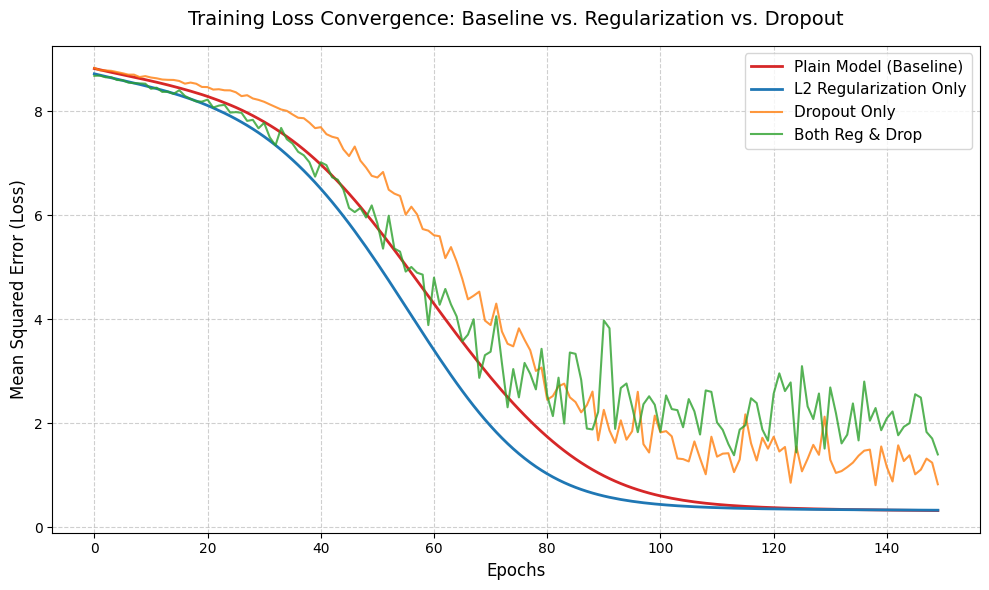

In [101]:
np.random.seed(69)
X_train = np.random.randn(150, 5)
y_train = X_train @ np.array([[1.5], [-2.0], [0.5], [1.0], [-1.0]]) + np.random.randn(150, 1) * 0.5

# Network A: Plain Model (No Regularization, No Dropout)
net_plain = ANN([
    Dense(5, 10), 
    Dense(10, 1, activation=False)
])

# Network B: L2 Regularization Only
net_reg = ANN([
    Dense(5, 10, l2_lambda=0.01), 
    Dense(10, 1, l2_lambda=0.01, activation=False) 
])

# Network C: Dropout Only
net_drop = ANN([
    Dense(5, 10), 
    Dropout(10, drop_rate=0.2),
    Dense(10, 1, activation=False)
])

# Network D: Both L2 and Dropout
net_both = ANN([
    Dense(5, 10, l2_lambda=0.01), 
    Dropout(10, drop_rate=0.3),
    Dense(10, 1, l2_lambda=0.01, activation=False)
])

learning_rate = 0.01
epochs = 150

def train_and_track(network, name):
    losses = []
    for i in range(epochs):
        y_pred = X_train
        for layer in network.layers:
            y_pred = layer.forward_pass(y_pred)
        
        loss = np.mean(np.square(y_pred - y_train))
        losses.append(loss)
        
        network.backward_pass(y_pred, y_train, learning_rate)
        
    print(f"{name} Final Training Loss: {losses[-1]:.4f}")
    return losses

loss_plain = train_and_track(net_plain, "Plain Model       ")
loss_reg = train_and_track(net_reg,   "Regularization Only")
loss_drop = train_and_track(net_drop, "Dropout Only      ")
loss_both = train_and_track(net_both, "Both Reg & Drop   ")

plt.figure(figsize=(10, 6))

# Plot all four loss arrays
plt.plot(loss_plain, label='Plain Model (Baseline)', color='#d62728', linewidth=2) # Red
plt.plot(loss_reg, label='L2 Regularization Only', color='#1f77b4', linewidth=2) # Blue
plt.plot(loss_drop, label='Dropout Only', color='#ff7f0e', alpha=0.8, linewidth=1.5) # Orange
plt.plot(loss_both, label='Both Reg & Drop', color='#2ca02c', alpha=0.8, linewidth=1.5) # Green

# Format the chart
plt.title('Training Loss Convergence: Baseline vs. Regularization vs. Dropout', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()